In [40]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

# Read in some colorectal cancer data
colorectal_data = pd.read_csv('Sample_Synthetic_Colorectal_Cancer_Global_Dataset.csv')
colorectal_data.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,74,M,Localized,45,No,No,Yes,Obese,...,No,Yes,35296,31,22,Urban,Developed,High,Insured,No
1,2,USA,59,M,Localized,42,Yes,No,No,Overweight,...,No,Yes,41402,19,23,Urban,Developing,Moderate,Uninsured,Yes
2,3,USA,77,F,Regional,15,No,No,Yes,Obese,...,Yes,No,83000,12,23,Urban,Developed,Moderate,Insured,No
3,4,Italy,87,M,Regional,65,No,No,Yes,Overweight,...,No,Yes,96168,18,16,Urban,Developed,Low,Insured,Yes
4,5,South Africa,63,F,Localized,73,No,No,No,Obese,...,No,Yes,109686,51,15,Rural,Developed,Moderate,Uninsured,Yes


In [41]:
# Suppose we're interested in the tumor size
tumor_size = colorectal_data.Tumor_Size_mm
tumor_size

0     45
1     42
2     15
3     65
4     73
      ..
95    76
96    22
97    70
98    73
99     9
Name: Tumor_Size_mm, Length: 100, dtype: int64

In [42]:
# Suppose we're predicting survival

survival_pred = (colorectal_data.Survival_Prediction == "Yes").astype(int)
survival_pred

0     0
1     1
2     0
3     1
4     1
     ..
95    0
96    1
97    1
98    0
99    1
Name: Survival_Prediction, Length: 100, dtype: int64

[0.00000000e+00 2.99099701e-02 5.95805410e-02 8.90127917e-02
 1.18207798e-01 1.47166634e-01 1.75890368e-01 2.04380069e-01
 2.32636802e-01 2.60661627e-01 2.88455604e-01 3.16019788e-01
 3.43355233e-01 3.70462988e-01 3.97344102e-01 4.23999619e-01
 4.50430580e-01 4.76638025e-01 5.02622989e-01 5.28386505e-01
 5.53929605e-01 5.79253314e-01 6.04358660e-01 6.29246662e-01
 6.53918340e-01 6.78374711e-01 7.02616788e-01 7.26645582e-01
 7.50462100e-01 7.74067349e-01 7.97462329e-01 8.20648040e-01
 8.43625480e-01 8.66395642e-01 8.88959518e-01 9.11318095e-01
 9.33472360e-01 9.55423295e-01 9.77171880e-01 9.98719093e-01
 1.02006591e+00 1.04121330e+00 1.06216223e+00 1.08291368e+00
 1.10346859e+00 1.12382794e+00 1.14399269e+00 1.16396378e+00
 1.18374217e+00 1.20332881e+00 1.22272465e+00 1.24193063e+00
 1.26094770e+00 1.27977679e+00 1.29841884e+00 1.31687478e+00
 1.33514555e+00 1.35323207e+00 1.37113527e+00 1.38885606e+00
 1.40639539e+00 1.42375415e+00 1.44093326e+00 1.45793364e+00
 1.47475620e+00 1.491401

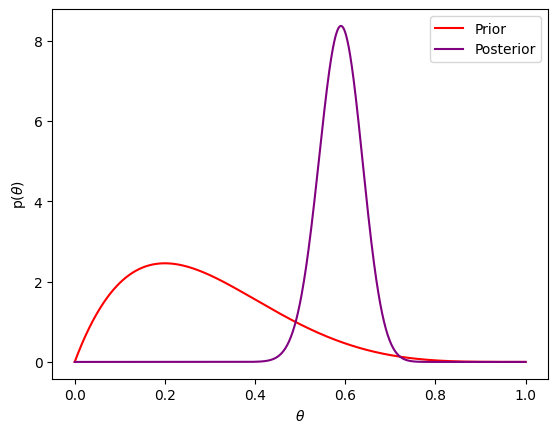

In [43]:
# We should use bernoulli distribution since outputs are 1 or 0

# Set up the prior distribution (Beta)
def prior(theta, alpha=2, beta=5):
    B = math.gamma(alpha) * math.gamma(beta) / math.gamma(alpha + beta)
    return (theta**(alpha-1))*((1-theta)**(beta-1))/(B)

# Set up the posterior (Also Beta)
def posterior(theta, alpha=2, beta=5):
    s = np.sum(survival_pred)   
    f = len(survival_pred) - s 
    
    alpha_post = alpha + s
    beta_post = beta + f
    
    B = math.gamma(alpha_post) * math.gamma(beta_post) / math.gamma(alpha_post + beta_post)
    
    return (theta**(alpha_post-1)) * ((1-theta)**(beta_post-1)) / B

sim_theta = np.linspace(0, 1, 1000, dtype=float)
prior_dist = prior(sim_theta)
posterior_dist = posterior(sim_theta)
print(prior_dist)
print(sim_theta[:10])

plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, posterior_dist, label = 'Posterior', color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show()
